# Imports

In [9]:
# Add the directory where starships' directory is located
from sys import path
path.append('/home/mathisb/Github/starships')

# Add the directory containing the input data (opacity, abundance and stellar specs files)
import os
os.environ['pRT_input_data_path'] = '/home/mathisb/projects/def-rdoyon/shared/Models/petitRADTRANS/input_data/'


In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import starships.homemade as hm
from starships import spectrum as spectrum
from starships.mask_tools import interp1d_masked

interp1d_masked.iprint=False
import warnings
from importlib import reload

import astropy.constants as const
import astropy.units as u
import numpy as np
import starships.planet_obs as pl_obs
import starships.plotting_fcts as pf
from starships.planet_obs import Observations

warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)

# Get planet info and determine directories to use

In [11]:
#--------------------------------------------------------------------------------------------
# Planet, night, reduction and instrument
pl_name = 'TRAPPIST-1 g'
visit_name = '2025-07-08'
reduction = "v001"
instrument = "NIRPS_Apr2026"  # SPIRou_with_persi, NIRPS, NIRPS_Apr2026

reduc_in_scratch = True  # True if the reductions are in scratch, False if in the Github folder
#--------------------------------------------------------------------------------------------

# Directory where to save reductions
if reduc_in_scratch:
    # > use scratch if available, use home if not
    try:
        out_dir = Path(os.environ['SCRATCH'])
    except KeyError:
        out_dir = Path.home()
else:
    out_dir = Path.home() / "Github/"

# Where are the reductions
pl_name_fname = ''.join(pl_name.split())
out_dir /= Path(f'HRS_reductions/{instrument}/{pl_name_fname}/{visit_name}/{reduction}')


In [12]:
# Relevant directories

# Where to find the observations (data)?
obs_dir = f"/home/mathisb/Github/HRS_data/{instrument}/TRAPPIST-1/{visit_name}/"

# Where to save figures?
path_fig = Path(f'HRS_reductions/{instrument}/{pl_name_fname}/{visit_name}/Figures')

In [13]:
# All the observations must be listed in files.
# We need the e2ds and the telluric corrected spectra.

list_filenames = {'list_e2ds': 'list_e2ds.txt',
                  'list_tcorr': 'list_tcorr.txt'}


In [14]:
# SPECIFY PARAMETERS OF THE PLANET
# If not specified, the default parameters from exofile are taken.

if pl_name == 'TRAPPIST-1 b':
    ap     = 0.01154*u.au        # semi-major axis of planet
    R_pl   = 1.116*u.R_earth     # radius of planet
    R_star = 0.1192*u.R_sun      # radius of star
    M_star = 0.0898*const.M_sun  # mass of star
    e      = 0                   # eccentricity
    w      = 4.712389*u.rad      # argument of periapsis (equal to 270 degrees)

elif pl_name == 'TRAPPIST-1 d':
    ap     = 0.02227*u.au        # semi-major axis of planet
    R_pl   = 0.788*u.R_earth     # radius of planet
    R_star = 0.1192*u.R_sun      # radius of star
    M_star = 0.0898*const.M_sun  # mass of star
    e      = 0                   # eccentricity
    w      = 4.712389*u.rad      # argument of periapsis (equal to 270 degrees)

elif pl_name == 'TRAPPIST-1 e':
    ap     = 0.02925*u.au        # semi-major axis of planet
    R_pl   = 0.920*u.R_earth     # radius of planet
    R_star = 0.1192*u.R_sun      # radius of star
    M_star = 0.0898*const.M_sun  # mass of star
    e      = 0                   # eccentricity
    w      = 4.712389*u.rad      # argument of periapsis (equal to 270 degrees)

elif pl_name == 'TRAPPIST-1 f':
    ap     = 0.03849*u.au        # semi-major axis of planet
    R_pl   = 1.045*u.R_earth     # radius of planet
    R_star = 0.1192*u.R_sun      # radius of star
    M_star = 0.0898*const.M_sun  # mass of star
    e      = 0                   # eccentricity
    w      = 4.712389*u.rad      # argument of periapsis (equal to 270 degrees)

elif pl_name == 'TRAPPIST-1 g':
    ap     = 0.04683*u.au        # semi-major axis of planet
    R_pl   = 1.129*u.R_earth     # radius of planet
    R_star = 0.1192*u.R_sun      # radius of star
    M_star = 0.0898*const.M_sun  # mass of star
    e      = 0                   # eccentricity
    w      = 4.712389*u.rad      # argument of periapsis (equal to 270 degrees)

else:
    raise ValueError(f"Please add the params for planet {pl_name}.")


# Mid-transit time (BJD) of each TRAPPIST-1 visit (calculated from Agol et al. 2024)
mid_tr_dict = {
        # SPIRou b
               "2019-06-14": 2458649.07123371738 * u.d,
               "2019-09-25": 2458751.8112203472  * u.d,
               "2020-05-31": 2459001.10676193183 * u.d,
               "2020-08-04": 2459066.07481311538 * u.d,
               "2020-09-08": 2459100.82490738839 * u.d,
               "2020-09-20": 2459112.91190875796 * u.d,
               "2020-09-26": 2459118.95517847751 * u.d,
               "2020-09-29": 2459121.9775049779  * u.d,
               "2021-10-21": 2459508.76251261068 * u.d,
               "2021-10-24": 2459511.78471495466 * u.d,
               "2021-10-27": 2459514.8059938763  * u.d,
        # NIRPS b
               "2023-09-07": 2460194.7007329288  * u.d,
               "2024-07-05": 2460496.8725766301  * u.d,
               "2024-07-11b": 2460502.9159761349 * u.d,
        # NIRPS d
               "2023-06-08": 2460103.8951073092 * u.d,
               "2023-08-12": 2460168.6902942523 * u.d,
               "2023-08-24": 2460180.8397053848 * u.d,
               "2023-10-20": 2460237.5365671548 * u.d,
        # NIRPS e
               "2023-07-17": 2460142.858565431  * u.d,
               "2023-11-04": 2460252.6376593957 * u.d,
               "2024-07-11e": 2460502.7365562134 * u.d,
        # NIRPS f
               "2023-08-28": 2460184.827486578  * u.d,
               "2024-11-02": 2460617.5481359637 * u.d,
               "2025-08-06": 2460893.795434583  * u.d,
        # NIRPS g
               "2023-10-05": 2460222.5638302773 * u.d,
               "2023-11-11": 2460259.6204310769 * u.d,
               "2025-07-08": 2460864.8974261757 * u.d,
                }

mid_tr = mid_tr_dict[visit_name]


if 'SPIRou' in instrument: instr_name = 'SPIRou-APERO'
elif 'NIRPS' in instrument: instr_name = 'NIRPS-APERO'

obs = Observations(name=pl_name, instrument=instr_name,
                   pl_kwargs = {'M_star': M_star, 
                                'R_star': R_star,
                                'ap': ap,
                                'R_pl': R_pl,
                                'mid_tr': mid_tr,
                                't_peri': mid_tr,
                                'excent': e,
                                'w': w})


# Get the data
obs.fetch_data(obs_dir, **list_filenames, CADC=True)
p = obs.planet

INFO:starships.planet_obs:Getting TRAPPIST-1 g from ExoFile
INFO:starships.planet_obs:Changing M_star from [1.5907279e+29] kg to 1.78559206388685e+29 kg
INFO:starships.planet_obs:It became [1.78559206e+29] kg
INFO:starships.planet_obs:Changing R_star from [0.] m to 0.1192 solRad
INFO:starships.planet_obs:It became [82927440.] m
INFO:starships.planet_obs:Changing ap from [7.00342432e+09] m to 0.04683 AU
INFO:starships.planet_obs:It became [7.00566828e+09] m
INFO:starships.planet_obs:Changing R_pl from [7220692.] m to 1.129 earthRad
INFO:starships.planet_obs:It became [7200874.9] m
INFO:starships.planet_obs:Changing mid_tr from [2457665.362844] d to 2460864.897426176 d
INFO:starships.planet_obs:It became [2460864.89742618] d
INFO:starships.planet_obs:Changing t_peri from [2457665.362844] d to 2460864.897426176 d
INFO:starships.planet_obs:It became [2460864.89742618] d
INFO:starships.planet_obs:Changing excent from pl_orbeccen
-----------
    0.00208 to 0
INFO:starships.planet_obs:It beca

# Look at the reductions

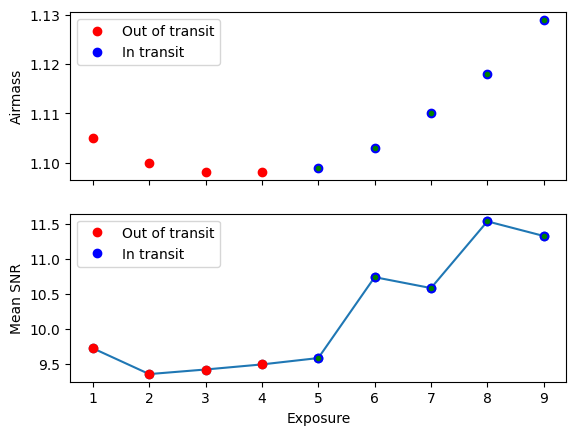

In [15]:
# Name of reduction sequence files
seq_file_list = [
                f"sequence_0-pc_mask_wings97_data_trs_{visit_name}.npz",
                # f"sequence_1-pc_mask_wings97_data_trs_{visit_name}.npz",
                ]

#----------------------------#

# Plot airmass and mean SNR
seq_obj_list = []

for seq_file in seq_file_list:
    sequence_obj = pl_obs.load_single_sequences(seq_file, name=pl_name, planet=p, path=out_dir, load_all=True)
    seq_obj_list.append(sequence_obj)

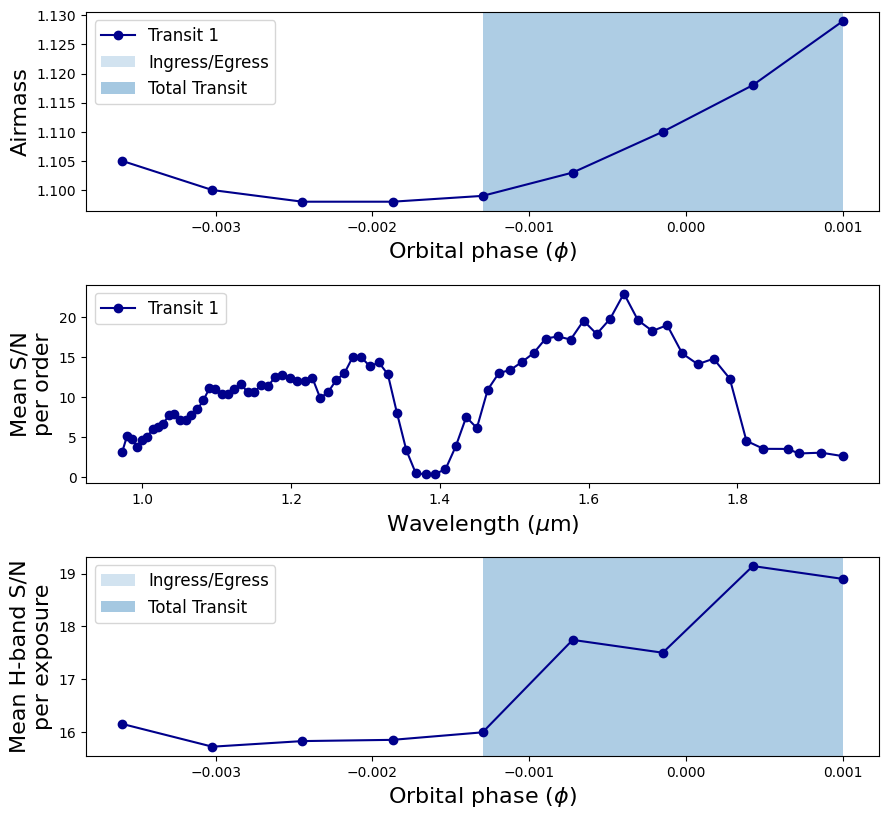

In [16]:
# Plot airmass and mean SNR per order/exposure

for seq_obj in seq_obj_list:
    pf.plot_airmass([seq_obj])

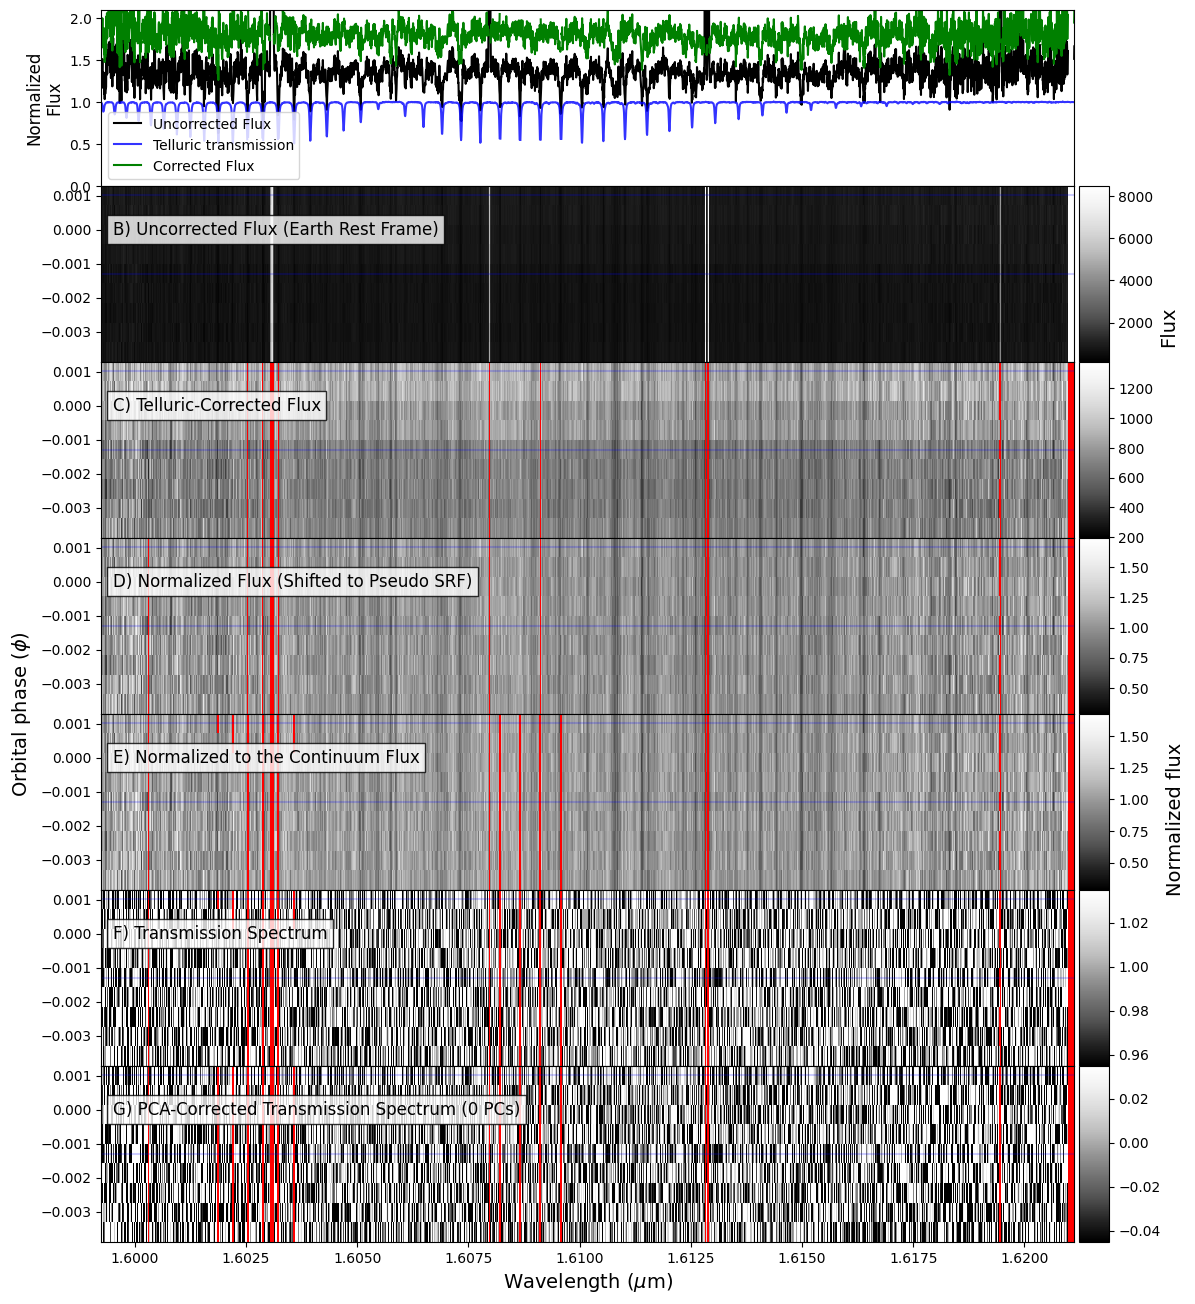

In [17]:
# Order to plot
order_plot = 60

#--------------#

# Plot the reductions steps
for seq_obj in seq_obj_list:
    plot_steps = pf.plot_steps(seq_obj, order_plot - 1)

plt.show()

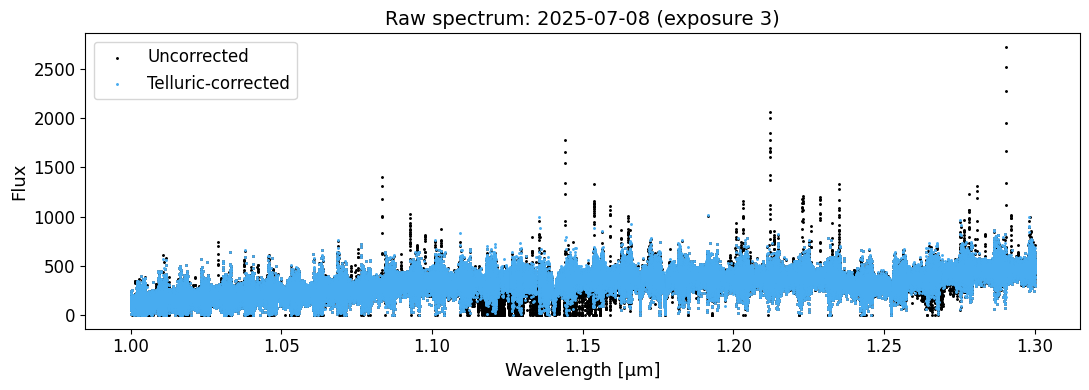

In [18]:
# PLOT ENTIRE SPECTRUM WITH OVERLAPPING ORDERS

exp_median = False  # take a median of the exposures
id_spec = 3  # exposure being plotted (ignored if exp_median = True)

wv_range = [1.0,1.3]  # wavelength range to plot, in microns

#-------------------------------------#

pf.plot_raw_spectrum(seq_obj, wv_range, visit_name, use_median=exp_median, exp_plot=id_spec, ylims=None)


In [11]:
# # Plot fewer steps

# for seq_obj in seq_obj_list:
#     plot_few_steps = pf.plot_five_steps(seq_obj, order_plot)

The fraction of masked data points is 0.47513807349423787


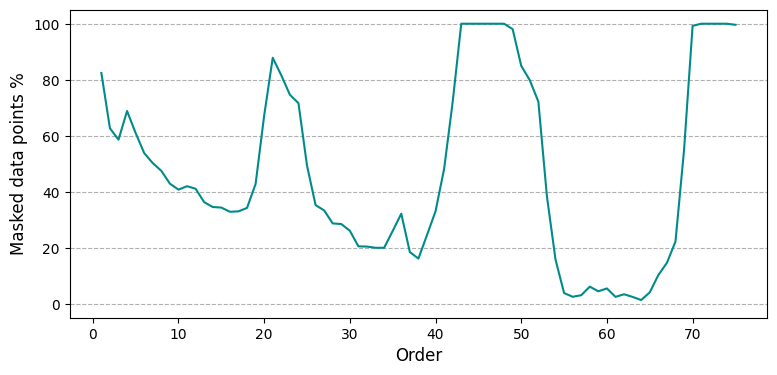

In [12]:
# Plot ratio of masked data points at each order

# Calculate overall ratio of masked data points
masked_ratio_total = [seq_obj.final.mask.sum() / seq_obj.final.size for seq_obj in seq_obj_list]
print("The fraction of masked data points is", masked_ratio_total[0])

# Plot ratio of masked data points per order, for each nPC
masked_ratio = np.array([seq_obj.final.mask.sum(axis=0).sum(axis=-1) / seq_obj.final.shape[0] / seq_obj.final.shape[-1]
                         for seq_obj in seq_obj_list])

n_pc_list = np.array([seq_obj.params[5] for seq_obj in seq_obj_list])  # list of nPC for each observation

fig, axs = plt.subplots(len(n_pc_list), sharex=True, squeeze=False, figsize=(9,4))

for n in range(len(n_pc_list)):
    order_list = np.arange(1, len(masked_ratio[n]) + 1)
    axs[n,0].plot(order_list, masked_ratio[n] * 100, color="darkcyan")
    axs[n,0].grid(axis='y', linestyle='--')
    axs[n,0].set_ylim(-5, 105)
#    axs[n,0].set_title("{} PC removed".format(n_pc_list[n]))

axs[len(n_pc_list) // 2, 0].set_ylabel("Masked data points %", fontsize=12)
plt.xlabel("Order", fontsize=12)
plt.show()

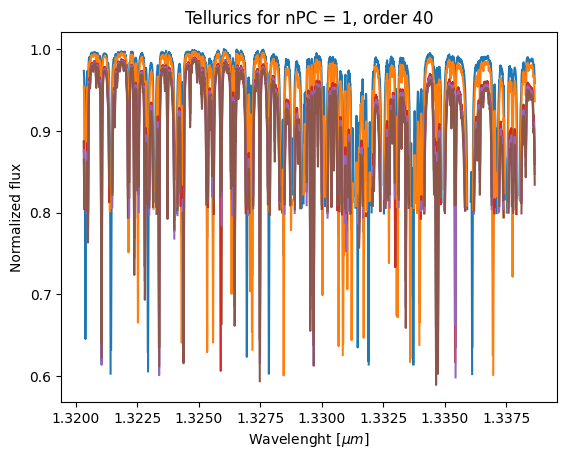

In [13]:
#-----------------------------------------------#
# Plot tellurics for a specific nPC and order
tellu_plot_nPC = 1
tellu_plot_order = 40
#-----------------------------------------------#

nPC_idx = np.where(n_pc_list == tellu_plot_nPC)[0][0]
plt.plot(seq_obj_list[nPC_idx].wave[:, tellu_plot_order, :].T, seq_obj_list[nPC_idx].tellu[:, tellu_plot_order, :].T)

plt.title("Tellurics for nPC = {}, order {}".format(tellu_plot_nPC, tellu_plot_order))
plt.xlabel("Wavelenght [$\mu{}m$]")
plt.ylabel("Normalized flux")
plt.show()

In [ ]:
#---------------------------------------------------------------#
# Plot final step of data reduction for a specific nPC and order
final_plot_nPC = 0
final_plot_order = 60
#---------------------------------------------------------------#

nPC_idx = np.where(n_pc_list == final_plot_nPC)[0][0]
pf.plot_order(seq_obj_list[nPC_idx], final_plot_order, xlabel="Wavelenght [$\mu{}m$]", ylabel="Exposure",
              title="Final step of data reduction for nPC = {}, order {}".format(final_plot_nPC, final_plot_order))

# Get some info about the observations

In [23]:
#--------------------------------------------------------------------------------------------
# Planet, night, reduction and instrument
pl_name = 'TRAPPIST-1 g'

nightlist = [
    # NIRPS b
            # '2023-09-07',
            # '2024-07-05',
            # '2024-07-11b',
    # NIRPS d
            # '2023-06-08',
            # '2023-08-12',
            # '2023-08-24',
            # '2023-10-20',
    # NIRPS e
            # '2023-07-17',
            # '2023-11-04',
            # '2024-07-11e',
    # NIRPS f
            # '2023-08-28',
            # '2024-11-02',
            # '2025-08-06',
    # NIRPS g
            '2023-10-05',
            '2023-11-11',
            '2025-07-08',
               ]

reduction = "v001"
instrument = "NIRPS_Apr2026"  # SPIRou_with_persi, NIRPS, NIRPS_Apr2026

reduc_in_scratch = True  # True if the reductions are in scratch, False if in the Github folder
#--------------------------------------------------------------------------------------------


In [24]:
pl_name_fname = ''.join(pl_name.split())

list_filenames = {'list_e2ds': 'list_e2ds.txt',
                  'list_tcorr': 'list_tcorr.txt'}

if pl_name == 'TRAPPIST-1 b':
    ap     = 0.01154*u.au        # semi-major axis of planet
    R_pl   = 1.116*u.R_earth     # radius of planet
    R_star = 0.1192*u.R_sun      # radius of star
    M_star = 0.0898*const.M_sun  # mass of star
    e      = 0                   # eccentricity
    w      = 4.712389*u.rad      # argument of periapsis (equal to 270 degrees)

elif pl_name == 'TRAPPIST-1 d':
    ap     = 0.02227*u.au        # semi-major axis of planet
    R_pl   = 0.788*u.R_earth     # radius of planet
    R_star = 0.1192*u.R_sun      # radius of star
    M_star = 0.0898*const.M_sun  # mass of star
    e      = 0                   # eccentricity
    w      = 4.712389*u.rad      # argument of periapsis (equal to 270 degrees)

elif pl_name == 'TRAPPIST-1 e':
    ap     = 0.02925*u.au        # semi-major axis of planet
    R_pl   = 0.920*u.R_earth     # radius of planet
    R_star = 0.1192*u.R_sun      # radius of star
    M_star = 0.0898*const.M_sun  # mass of star
    e      = 0                   # eccentricity
    w      = 4.712389*u.rad      # argument of periapsis (equal to 270 degrees)

elif pl_name == 'TRAPPIST-1 f':
    ap     = 0.03849*u.au        # semi-major axis of planet
    R_pl   = 1.045*u.R_earth     # radius of planet
    R_star = 0.1192*u.R_sun      # radius of star
    M_star = 0.0898*const.M_sun  # mass of star
    e      = 0                   # eccentricity
    w      = 4.712389*u.rad      # argument of periapsis (equal to 270 degrees)

elif pl_name == 'TRAPPIST-1 g':
    ap     = 0.04683*u.au        # semi-major axis of planet
    R_pl   = 1.129*u.R_earth     # radius of planet
    R_star = 0.1192*u.R_sun      # radius of star
    M_star = 0.0898*const.M_sun  # mass of star
    e      = 0                   # eccentricity
    w      = 4.712389*u.rad      # argument of periapsis (equal to 270 degrees)

else:
    raise ValueError(f"Please add the params for planet {pl_name}.")


# Mid-transit time (BJD) of each TRAPPIST-1 visit (calculated from Agol et al. 2024)
mid_tr_dict = {
        # NIRPS b
               "2023-09-07": 2460194.7007329288  * u.d,
               "2024-07-05": 2460496.8725766301  * u.d,
               "2024-07-11b": 2460502.9159761349 * u.d,
        # NIRPS d
               "2023-06-08": 2460103.8951073092 * u.d,
               "2023-08-12": 2460168.6902942523 * u.d,
               "2023-08-24": 2460180.8397053848 * u.d,
               "2023-10-20": 2460237.5365671548 * u.d,
        # NIRPS e
               "2023-07-17": 2460142.858565431  * u.d,
               "2023-11-04": 2460252.6376593957 * u.d,
               "2024-07-11e": 2460502.7365562134 * u.d,
        # NIRPS f
               "2023-08-28": 2460184.827486578  * u.d,
               "2024-11-02": 2460617.5481359637 * u.d,
               "2025-08-06": 2460893.795434583  * u.d,
        # NIRPS g
               "2023-10-05": 2460222.5638302773 * u.d,
               "2023-11-11": 2460259.6204310769 * u.d,
               "2025-07-08": 2460864.8974261757 * u.d,
                }

INFO:starships.planet_obs:Getting TRAPPIST-1 g from ExoFile
INFO:starships.planet_obs:Changing M_star from [1.5907279e+29] kg to 1.78559206388685e+29 kg
INFO:starships.planet_obs:It became [1.78559206e+29] kg
INFO:starships.planet_obs:Changing R_star from [0.] m to 0.1192 solRad
INFO:starships.planet_obs:It became [82927440.] m
INFO:starships.planet_obs:Changing ap from [7.00342432e+09] m to 0.04683 AU
INFO:starships.planet_obs:It became [7.00566828e+09] m
INFO:starships.planet_obs:Changing R_pl from [7220692.] m to 1.129 earthRad
INFO:starships.planet_obs:It became [7200874.9] m
INFO:starships.planet_obs:Changing mid_tr from [2457665.362844] d to 2460222.5638302774 d
INFO:starships.planet_obs:It became [2460222.56383028] d
INFO:starships.planet_obs:Changing t_peri from [2457665.362844] d to 2460222.5638302774 d
INFO:starships.planet_obs:It became [2460222.56383028] d
INFO:starships.planet_obs:Changing excent from pl_orbeccen
-----------
    0.00208 to 0
INFO:starships.planet_obs:It be

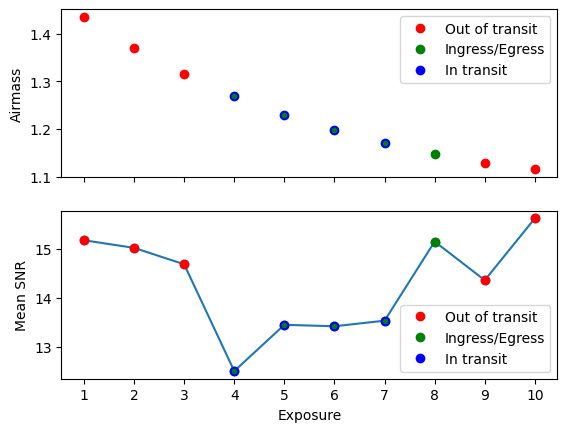

INFO:starships.planet_obs:Getting TRAPPIST-1 g from ExoFile


2023-10-05: RV variation during transit: 0.790137421612602 km / s



INFO:starships.planet_obs:Changing M_star from [1.5907279e+29] kg to 1.78559206388685e+29 kg
INFO:starships.planet_obs:It became [1.78559206e+29] kg
INFO:starships.planet_obs:Changing R_star from [0.] m to 0.1192 solRad
INFO:starships.planet_obs:It became [82927440.] m
INFO:starships.planet_obs:Changing ap from [7.00342432e+09] m to 0.04683 AU
INFO:starships.planet_obs:It became [7.00566828e+09] m
INFO:starships.planet_obs:Changing R_pl from [7220692.] m to 1.129 earthRad
INFO:starships.planet_obs:It became [7200874.9] m
INFO:starships.planet_obs:Changing mid_tr from [2457665.362844] d to 2460259.6204310767 d
INFO:starships.planet_obs:It became [2460259.62043108] d
INFO:starships.planet_obs:Changing t_peri from [2457665.362844] d to 2460259.6204310767 d
INFO:starships.planet_obs:It became [2460259.62043108] d
INFO:starships.planet_obs:Changing excent from pl_orbeccen
-----------
    0.00208 to 0
INFO:starships.planet_obs:It became 0
INFO:starships.planet_obs:Changing w from [8.05190197

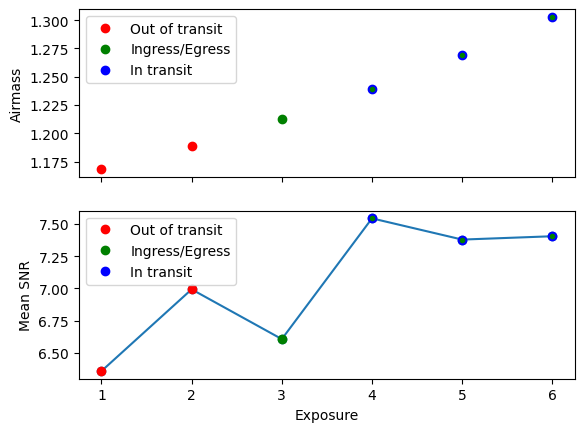

INFO:starships.planet_obs:Getting TRAPPIST-1 g from ExoFile


2023-11-11: RV variation during transit: 0.4464603834780144 km / s



INFO:starships.planet_obs:Changing M_star from [1.5907279e+29] kg to 1.78559206388685e+29 kg
INFO:starships.planet_obs:It became [1.78559206e+29] kg
INFO:starships.planet_obs:Changing R_star from [0.] m to 0.1192 solRad
INFO:starships.planet_obs:It became [82927440.] m
INFO:starships.planet_obs:Changing ap from [7.00342432e+09] m to 0.04683 AU
INFO:starships.planet_obs:It became [7.00566828e+09] m
INFO:starships.planet_obs:Changing R_pl from [7220692.] m to 1.129 earthRad
INFO:starships.planet_obs:It became [7200874.9] m
INFO:starships.planet_obs:Changing mid_tr from [2457665.362844] d to 2460864.897426176 d
INFO:starships.planet_obs:It became [2460864.89742618] d
INFO:starships.planet_obs:Changing t_peri from [2457665.362844] d to 2460864.897426176 d
INFO:starships.planet_obs:It became [2460864.89742618] d
INFO:starships.planet_obs:Changing excent from pl_orbeccen
-----------
    0.00208 to 0
INFO:starships.planet_obs:It became 0
INFO:starships.planet_obs:Changing w from [8.05190197] 

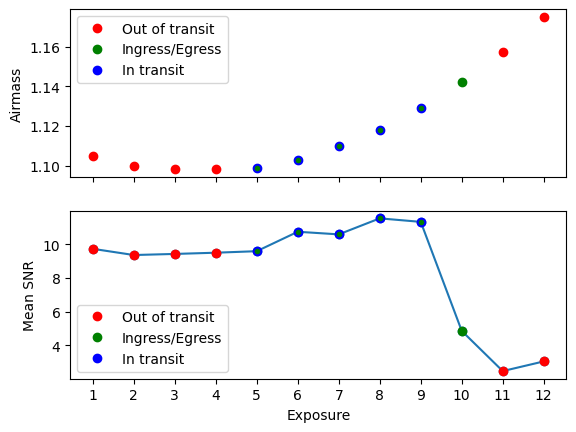

2025-07-08: RV variation during transit: 0.7442341033998594 km / s



In [25]:
for visit_name in nightlist:
    # Directory where to save reductions
    if reduc_in_scratch:
        # > use scratch if available, use home if not
        try:
            out_dir = Path(os.environ['SCRATCH'])
        except KeyError:
            out_dir = Path.home()
    else:
        out_dir = Path.home() / "Github/"
    
    # Where are the reductions
    out_dir /= Path(f'HRS_reductions/{instrument}/{pl_name_fname}/{visit_name}/{reduction}')

    # Where to find the observations (data)?
    obs_dir = f"/home/mathisb/Github/HRS_data/{instrument}/TRAPPIST-1/{visit_name}/"

    mid_tr = mid_tr_dict[visit_name]
    
    obs = Observations(name=pl_name, instrument='NIRPS-APERO',
                       pl_kwargs = {'M_star': M_star, 
                                    'R_star': R_star,
                                    'ap': ap,
                                    'R_pl': R_pl,
                                    'mid_tr': mid_tr,
                                    't_peri': mid_tr,
                                    'excent': e,
                                    'w': w})
    
    # Get the data
    obs.fetch_data(obs_dir, **list_filenames, CADC=True)
    p = obs.planet

    seq_obj = pl_obs.load_single_sequences(f"sequence_0-pc_mask_wings97_data_trs_{visit_name}.npz", name=pl_name, planet=p, path=out_dir, load_all=True)

    pl_obs.gen_rv_sequence(seq_obj, p)

    rv_var = seq_obj.vrp[seq_obj.alpha_frac > 0][-1] - seq_obj.vrp[seq_obj.alpha_frac > 0][0]

    print(f"{visit_name}: RV variation during transit: {rv_var}")
    print("")
    

    

b

2023-09-07: RV variation during transit: 4.033301752935504 km / s

2024-07-05: RV variation during transit: 4.902690644463125 km / s

2024-07-11b: RV variation during transit: 4.0336659256576635 km / s

d

2023-06-08: RV variation during transit: 1.7480182129711554 km / s

2023-08-12: RV variation during transit: 0.9218806761988605 km / s

2023-08-24: RV variation during transit: 1.191216901558486 km / s

2023-10-20: RV variation during transit: 1.9751594345902586 km / s

e

2023-07-17: RV variation during transit: 1.5186991448503042 km / s

2023-11-04: RV variation during transit: 1.9066929853068355 km / s

2024-07-11e: RV variation during transit: 1.2482546310349678 km / s

f

2023-08-28: RV variation during transit: 0.979232666262697 km / s

2024-11-02: RV variation during transit: 1.1012714238721903 km / s

2025-08-06: RV variation during transit: 1.1014179730361922 km / s

g

2023-10-05: RV variation during transit: 0.790137421612602 km / s

2023-11-11: RV variation during transit: 0.4464603834780144 km / s

2025-07-08: RV variation during transit: 0.7442341033998594 km / s


In [43]:
def wavelength_info(wavelengths):
    """
    Calculate the mean wavelength and mean wavelength spacing for each order.
    """
    mean_wavelength = np.mean(wavelengths, axis=1)
    mean_spacing = np.mean(np.diff(wavelengths, axis=1), axis=1)

    return mean_wavelength, mean_spacing

In [50]:
print((const.c * (delta_wv / mean_wv)).to(u.km/u.s))

[1.01414607 1.01474486 1.0157432  1.01645476 1.01702268 1.01747903
 1.01813912 1.01861736 1.01895011 1.01935591 1.01972572 1.01992028
 1.02015359 1.02026538 1.02050192 1.02052423 1.02048836 1.02057398
 1.02046204 1.02032778 1.02016599 1.02001956 1.01985828 1.01963264
 1.01931595 1.01902981 1.01875253 1.01836638 1.01792435 1.01749446
 1.01707834 1.01660247 1.01606193 1.01554762 1.01505101 1.01445336
 1.01387212 1.01328002 1.01263022 1.01199596 1.01132207 1.0106402
 1.00995461 1.00897106 1.00848471 1.00773804 1.00719418 1.00624352
 1.00542946 1.00464244 1.00383092 1.00300681 1.00217424 1.00132308
 1.00048332 0.99961377 0.99874203 0.99786657 0.99696686 0.99606836
 0.99516493 0.99426785 0.99338289 0.99245147 0.99152387 0.99058636
 0.98963972 0.98868681 0.98772542 0.98678334 0.98580022 0.9895065
 0.98385709 0.98554847 0.98646008] km / s
